# LangGraph 101: Building Your First Agent

<img src="../../images/react_agent.png" style="width: auto; max-height: 500px; border-radius: 8px;">

Welcome to LangGraph 101! This notebook will walk you through the core concepts of building agents with LangChain and LangGraph.

**What you'll learn:**
- How to interact with language models
- Working with messages and conversation
- Adding tools to extend LLM capabilities
- Building an agent that can reason and act
- Adding memory to maintain context
- Streaming responses for better UX
<br> 
<br> 
---
<br> 

> **Note:** This tutorial uses LangChain v1 (alpha), which provides the easiest way to start building with LLMs. LangChain agents are built on top of LangGraph, providing durable execution, streaming, human-in-the-loop, and persistence out of the box.

## Part 0: Setup & Installation

First, let's install the necessary packages and set up our environment.

In [1]:
# Install required packages 
# Run uv sync to install the packages or run:
# !pip install --pre -U langchain langchain-anthropic langchain-openai python-dotenv

### Intialize your LLM

In [22]:
# Add project root to Python path so we can import from utils module
import sys
from pathlib import Path
project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Alternative: If you want to define the model inline instead of using centralized config, uncomment below:
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env", override=True)

# Note: For other providers (Azure, Bedrock, Vertex AI), update utils/models.py
# See utils/models.py for detailed instructions on switching LLM providers

# Suppress warning for uuid v7 for simple examples without thread id's
import warnings
warnings.filterwarnings('ignore', message='LangSmith now uses UUID v7')

## Part 1: Your First LLM Call

LangChain provides a **standard model interface** that works across all providers. 

This means you can easily swap between OpenAI, Anthropic, Google, and other providers without changing your code.

Let's start by initializing a chat model.

In [24]:
# INITIALIZE A CHAT MODEL
from langchain.chat_models import init_chat_model

model = init_chat_model("openai:gpt-4.1-mini")

# MAKE YOUR FIRST CALL
response = model.invoke("What is LangChain?")
response.pretty_print()

================================== Ai Message ==================================

LangChain is a framework designed to help developers build applications that integrate large language models (LLMs) with other sources of data and computational logic. It provides tools and abstractions to manage prompts, chain together calls to language models, connect to external data sources or APIs, and handle memory and state in conversational or multi-step workflows.

Key features of LangChain include:

- **Prompt Management:** Utilities for creating, formatting, and managing prompts that are sent to language models.
- **Chains:** Ability to link together multiple steps or calls to LLMs and other components to build complex workflows.
- **Agents:** Components that can decide which actions to take based on user input and context, such as querying APIs or databases.
- **Memory:** Support for stateful interactions, enabling conversation history or context to be stored and referenced.
- **Integrations:*

### Key Takeaway:
- `init_chat_model()` gives you a standardized interface to any LLM provider
- `.invoke()` sends a message and returns a response
- No provider lock-in - swap models easily!

## Part 2: Understanding Messages

**Messages** are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both content and metadata.

There are different message types:
- **SystemMessage** - Instructions for how the model should behave
- **HumanMessage** - User input
- **AIMessage** - Model responses
- **ToolMessage** - Results from tool executions

In [4]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

# CREATE A CONVERSATION BETWEEN A SYSTEM AND A HUMAN WITH DIFFERENT MESSAGE TYPES
messages = [
    SystemMessage(content="You are a helpful AI assistant that explains technical concepts simply."),   # THIS IS THE SYSTEM PROMPT
    HumanMessage(content="What is an agent?"),                                                          # THIS IS THE HUMAN'S INPUT
]

response = model.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

An **agent** is something that can act on its own to achieve goals or perform tasks. In different contexts, it can mean:

- **In computer science and artificial intelligence:** An agent is a program or system that perceives its environment through sensors and acts upon that environment through actuators to achieve specific objectives. For example, a chatbot or a robot can be considered an agent.

- **In economics or business:** An agent is a person or entity authorized to act on behalf of another, like a sales agent or real estate agent.

- **In general language:** An agent can be a person who causes something to happen or take action.

If you want, I can explain more about agents in a specific field!


### Multi-turn Conversations

Messages make it easy to maintain conversation history:

In [5]:
# CONTINUE THE CONVERSATION

messages.append(response)  # ADD AI RESPONSE TO THE MESSAGE HISTORY 
messages.append(HumanMessage(content="Can you give me an example?"))    # WHEN WE ASK THIS FOLLOW-UP QUESTION, THE LLM REMEMBERS THE PRIOR CONVERSATION

response = model.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

Certainly! Here’s an example of an **agent** in the context of artificial intelligence:

**Example: A Roomba Robot Vacuum**

- **Environment:** Your home floor
- **Agent:** The Roomba vacuum robot
- **Sensors:** Cameras, infrared sensors, bump sensors to detect obstacles and dirt
- **Actuators:** Wheels to move around, vacuum motor to clean
- **Goal:** Clean the floor efficiently without bumping into furniture or falling down stairs

The Roomba senses the environment, decides where to move next, and takes actions to clean the floor. It acts autonomously to achieve its goal, so it’s considered an intelligent agent.

If you want, I can give you examples from other areas too!


### Key Takeaway:
- **Messages** represent the conversation history
- **SystemMessage** sets the model's behavior
- Build **multi-turn conversations** by appending messages to a list

## Part 3: Adding Tools - Extending LLM Capabilities

LLMs are great at language, but they can't access external data or perform actions. **Tools** extend their capabilities. 

You can give an LLM a list of tools, and when it needs one, it will specify which tool to call. 

You can create a tool just by writing a Python function with a clear description. LangChain's `@tool` decorator handles formatting the function's information in the LLM's desired format.  

Let's create some simple tools:

In [6]:
import requests
import json
from langchain_core.tools import tool

# Basic hardcoded tool
@tool
def search_movies(genre: str) -> str:
    """Search for movies by genre.
    
    Args:
        genre: The genre of movie to search for
        
    Returns:
        A string with a list of movies in that genre
    """
    # In a real app, this would query a movie database
    movies = {
        "sci-fi": "Dune, Interstellar, Blade Runner 2049",
        "comedy": "The Grand Budapest Hotel, Superbad, Knives Out",
        "action": "Mad Max: Fury Road, John Wick, Mission Impossible"
    }
    return movies.get(genre.lower(), "No movies found for that genre")

# More realistic tool that calls an API
@tool
def get_weather(latitude: float, longitude: float) -> str:
    """Get current temperature in Fahrenheit and weather code for given coordinates.

    Args:
        latitude: Latitude coordinate
        longitude: Longitude coordinate

    Returns:
        JSON string with temperature_fahrenheit and weather_code (do not include the code in your response, translate it to plain English)
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": "temperature_2m,weather_code",
        "temperature_unit": "fahrenheit"
    }

    weather = requests.get(url, params=params).json()["current"]
    temperature = weather["temperature_2m"]
    weather_code = weather["weather_code"]
    result = {
        "temperature_fahrenheit": temperature,
        "weather_code": weather_code
    }

    return json.dumps(result)



# Test a tool directly with SF's coordinates
print(get_weather.invoke({"latitude": 37.77, "longitude": 122.42}))

{"temperature_fahrenheit": 53.0, "weather_code": 0}


### Tool Calling (Function Calling)

Now let's give these tools to the model using `.bind_tools()`:

In [7]:
# WE HAVE TO "BIND" TOOLS TO THE MODEL SO THAT IT IS AWARE OF WHAT TOOLS IT HAS AND WHEN TO CALL THEM

tools = [get_weather, search_movies]
model_with_tools = model.bind_tools(tools)
message = "What's the weather like in Seattle? (Seattle's coordinates are approximately 47.6° N latitude and 122.33° W longitude) "

# The model can now decide to call tools
response = model_with_tools.invoke(message)

# Check if the model wants to call a tool
print("Tool calls: ", response.pretty_print())

================================== Ai Message ==================================
Tool Calls:
  get_weather (call_OQ7xSPW2oz9BOO1opqVMh7aF)
 Call ID: call_OQ7xSPW2oz9BOO1opqVMh7aF
  Args:
    latitude: 47.6
    longitude: -122.33
Tool calls:  None


**Notice that the LLM did not actually call the tool yet. It merely told us what tool it wanted to call.**

The model returns a **tool call** request with:
- `name`: Which tool to call
- `args`: Arguments to pass to the tool
- `id`: Unique identifier for tracking

Let's execute the tool and continue the conversation.

**NOTE:** This is a lot of code. Don't worry. We do not actually do all of this in a real agent. The LangChain framework handles this for us!

In [8]:
from langchain.messages import ToolMessage

# Execute the tool call
if response.tool_calls:
    tool_call = response.tool_calls[0]

    # Call the actual tool
    if tool_call["name"] == "get_weather":
        result = get_weather.invoke(tool_call["args"])

    elif tool_call["name"] == "search_movies":
        result = search_movies.invoke(tool_call["args"])

    # Create a ToolMessage with the result
    tool_message = ToolMessage(
        content=result,
        tool_call_id=tool_call["id"]
    )

    # Continue the conversation with the tool result
    final_response = model_with_tools.invoke([
        HumanMessage(content=message),
        response,
        tool_message
    ])

    final_response.pretty_print()

================================== Ai Message ==================================

The weather in Seattle is currently clear with a temperature of about 64.2°F. Would you like to know anything else?


### Key Takeaway:
- Tools are Python functions decorated with `@tool`
- Good descriptions help the model know when to use each tool
- Tool calling flow: Model requests tool → Execute tool → Return result → Model synthesizes final response

## Part 4: Building Your First Agent with `create_agent()`

<img src="../../images/react_agent.png" style="width: auto; max-height: 500px; border-radius: 8px;">

Manually defining a specific sequence of LLM calls and tool calls is tedious and inflexible. Instead, we can use an **agent** that runs this loop:
1. Model decides which tool to call (if any)
2. Tool gets executed
3. Result goes back to model
4. Repeat until task is complete

LangChain makes this easy with `create_agent()` - **build an agent in ~10 lines of code!**
The prebuilt agent handles running the loop described above - you just specify the system prompt and tools. 

This is the **ReAct** pattern we have been discussing!

In [9]:
from langchain.agents import create_agent

# Create an agent with tools
agent = create_agent(
    model=model,
    tools=[get_weather, search_movies],
    system_prompt="You are a helpful assistant that can check weather and recommend movies."
)

# Use the agent
result = agent.invoke({
    "messages": [HumanMessage(content="What's the weather in NYC? (40.71° N, 74.01° W) Also recommend some sci-fi movies.")]
})

# Print the final response
for message in result["messages"]:
    message.pretty_print()
    print("\n")

================================ Human Message =================================

What's the weather in NYC? (40.71° N, 74.01° W) Also recommend some sci-fi movies.


================================== Ai Message ==================================
Tool Calls:
  get_weather (call_8y6xHqFyxrTyfgbmfSvj55BJ)
 Call ID: call_8y6xHqFyxrTyfgbmfSvj55BJ
  Args:
    latitude: 40.71
    longitude: -74.01
  search_movies (call_C7VbKXAS2dP4vvMmRdPNXm7y)
 Call ID: call_C7VbKXAS2dP4vvMmRdPNXm7y
  Args:
    genre: sci-fi


================================= Tool Message =================================
Name: get_weather

{"temperature_fahrenheit": 49.6, "weather_code": 3}


================================= Tool Message =================================
Name: search_movies

Dune, Interstellar, Blade Runner 2049


================================== Ai Message ==================================

The current temperature in New York City is about 49.6°F with cloudy weather. For some great sci-fi movies, I 

### What just happened?

The agent automatically:
1. Analyzed the user's request
2. Called `get_weather("NYC")`
3. Called `search_movies("sci-fi")`
4. Synthesized the results into a natural response

Let's visualize the agent's structure:

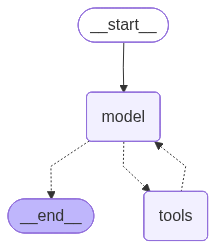

In [10]:
agent

### Key Takeaway:
- `create_agent()` builds a complete agent in ~10 lines
- The agent automatically handles the reasoning → action → observation loop
- Built on LangGraph for production features (persistence, streaming, human-in-the-loop)

## Part 5: Adding Memory & State

Right now, each agent invocation is independent. Let's add **memory** so the agent can maintain context across multiple interactions.

LangGraph uses **checkpointers** to save and restore state:

In [11]:
from langgraph.checkpoint.memory import MemorySaver
from langsmith import uuid7

# Create a checkpointer for memory
checkpointer = MemorySaver()

# Create an agent with memory
agent_with_memory = create_agent(
    model=model,
    tools=[get_weather, search_movies],
    system_prompt="You are a helpful assistant.",
    checkpointer=checkpointer
)

# Create a thread for this conversation
config = {"configurable": {"thread_id": uuid7()}}   # THREADS ARE HOW WE TRACK MULTI-TURN CONVERSATIONS BETWEEN HUMANS AND LLMS

# First interaction
result1 = agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "My name is Alice and I love sci-fi movies."}]},
    config=config
)

print("Response 1:", result1["messages"][-1].content)

# Second interaction - the agent remembers!
result2 = agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What's my name and what movies do I like?"}]},
    config=config
)
print("\nResponse 2:", result2["messages"][-1].content)

Response 1: Hi Alice! It's great to meet a fellow sci-fi movie fan. Would you like some recommendations for sci-fi movies to watch?

Response 2: Your name is Alice, and you like sci-fi movies. Would you like me to recommend some sci-fi movies for you?


### Understanding State & Threads

- **State**: The agent's "memory" - includes message history and any custom data
- **Thread**: A conversation session identified by `thread_id`
- **Checkpointer**: Saves state after each step, enabling memory and error recovery

Each thread is independent:

In [12]:
# New thread - agent won't remember Alice
new_config_with_new_thread_id = {"configurable": {"thread_id": uuid7()}}    # WITH A NEW THREAD OUR LLLM WILL NOT REMEMBER OUR NAME FROM THE PREVIOUS CONVERSATION

result3 = agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What's my name?"}]},
    config=new_config_with_new_thread_id
)
print("New thread response:", result3["messages"][-1].content)

New thread response: I don't have access to your name. Could you please tell me your name?


### Key Takeaway:
- Checkpointers enable memory across interactions
- Thread IDs separate different conversations
- State persists automatically - no manual state management needed!

## Part 6: Streaming for Better UX

LLMs can take a while to respond. **Streaming** shows progress in real-time, dramatically improving user experience.

LangChain supports multiple streaming modes:

### Streaming Agent Steps

In [13]:
# Stream agent progress with stream_mode="updates"
print("Streaming agent steps:\n")

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What's the weather in Boston? (42.36° N, 71.06° W) "}]},
    stream_mode="updates"
):
    for node_name, data in chunk.items():
        print(f"Step: {node_name}")
        if "messages" in data:
            message = data["messages"][-1]
            if hasattr(message, 'tool_calls') and message.tool_calls:
                print(f"   Tool call: {message.tool_calls[0]['name']}")
            elif hasattr(message, 'content'):
                print(f"   Content: {message.content[:100]}..." if len(message.content) > 100 else f"   Content: {message.content}")
        print()

Streaming agent steps:

Step: model
   Tool call: get_weather

Step: tools
   Content: {"temperature_fahrenheit": 46.1, "weather_code": 3}

Step: model
   Content: The current weather in Boston is 46.1°F with scattered clouds. Would you like to know anything else?



### Streaming LLM Tokens

For a ChatGPT-like experience, stream tokens as they're generated:

In [14]:
# Stream tokens with stream_mode="messages"
print("Streaming tokens:\n")

for token, metadata in agent.stream(
    {"messages": [{"role": "user", "content": "Tell me about LangGraph in 10 sentences."}]},
    stream_mode="messages"
):
    # Only print content from the model node
    if metadata.get('langgraph_node') == 'model':
        # Get text from content blocks
        for block in token.content_blocks:
            if block.get('type') == 'text' and block.get('text'):
                print(block['text'], end='', flush=True)

print("\n")  # New line at the end

Streaming tokens:

LangGraph is an innovative framework or tool designed to facilitate the construction and management of language models and natural language processing tasks. It emphasizes the representation of linguistic knowledge and information in a graph structure, enabling more intuitive and efficient manipulation of language data. By leveraging graph theory, LangGraph allows for the modeling of complex relationships between words, phrases, and concepts within a language. This approach can enhance various NLP applications, including semantic search, machine translation, and text summarization. LangGraph supports the integration of external knowledge bases, enriching the language models with real-world information. It often includes tools for visualizing language graphs, aiding researchers and developers in understanding and debugging language models. The framework is designed to be flexible and extensible, accommodating different languages and linguistic phenomena. LangGraph pro

### Key Takeaway:
- `stream_mode="updates"` - See each agent step (useful for debugging)
- `stream_mode="messages"` - Stream LLM tokens (ChatGPT-like UX)
- Streaming is built-in - no extra setup required!

## Part 7: Putting It All Together - A Practical Example

Let's build a more realistic agent that combines everything we've learned:

In [15]:
# Create more realistic tools
@tool
def get_user_preferences(user_id: str) -> str:
    """Get a user's saved preferences."""
    # Simulate a user database
    preferences = {
        "alice": "Loves sci-fi movies, prefers warm weather destinations",
        "bob": "Enjoys comedy films, likes cold climates for travel"
    }
    return preferences.get(user_id.lower(), "No preferences found")

@tool
def book_recommendation(genre: str, user_preferences: str = "") -> str:
    """Get personalized movie recommendations based on genre and user preferences."""
    recommendations = {
        "sci-fi": "Based on your preferences, try: Arrival, Ex Machina, or The Martian",
        "comedy": "Based on your preferences, try: The Big Lebowski, Anchorman, or Bridesmaids"
    }
    return recommendations.get(genre.lower(), "No recommendations available")

# Create a helpful assistant agent
assistant = create_agent(
    model=model,
    tools=[get_weather, get_user_preferences, book_recommendation],
    system_prompt="""You are a helpful personal assistant.

    You can:
    - Check weather for any city
    - Look up user preferences
    - Recommend movies based on preferences

    Always be friendly and personalize your responses based on user preferences.""",
    checkpointer=MemorySaver()
)

# USE A NEW THREAD ID TO START A NEW CONVERSATION
config = {"configurable": {"thread_id": uuid7()}}

print("=" * 50)
print("PERSONAL ASSISTANT DEMO")
print("=" * 50 + "\n")

# Interaction 1
print("User: Hi, I'm Alice. Can you check my preferences and recommend a movie?\n")
result = assistant.invoke(
    {"messages": [{"role": "user", "content": "Hi, I'm Alice. Can you check my preferences and recommend a movie?"}]},
    config=config
)
print(f"Assistant: {result['messages'][-1].content}\n")

# Interaction 2
print("User: Also, what's the weather like in San Francisco? (37.77° N, 122.42° W) \n")
result = assistant.invoke(
    {"messages": [{"role": "user", "content": "Also, what's the weather like in San Francisco? (37.77° N, 122.42° W) "}]},
    config=config
)
print(f"Assistant: {result['messages'][-1].content}\n")

print("=" * 50)

PERSONAL ASSISTANT DEMO

User: Hi, I'm Alice. Can you check my preferences and recommend a movie?

Assistant: Hi Alice! Based on your preferences for sci-fi movies and warm weather destinations, I recommend watching Arrival, Ex Machina, or The Martian. Let me know if you'd like more information about any of these or if you want additional recommendations!

User: Also, what's the weather like in San Francisco? (37.77° N, 122.42° W) 

Assistant: The weather in San Francisco is currently 62.8°F with clear skies. It's a pleasant day there! If you need anything else, just let me know.



## Part 8: Next Steps - Exploring LangGraph Primitives

We've been using `create_agent()`, which is built on **LangGraph**. LangGraph gives you full control over agent behavior using three core primitives:

### Core LangGraph Concepts:

1. **State** 
   - Shared data structure passed between nodes
   - Represents the agent's "memory"
   - Can include messages, custom data, etc.

2. **Nodes** 
   - Python functions that process state
   - Each node performs a specific task
   - Examples: call LLM, execute tool, validate input

3. **Edges** 
   - Define flow between nodes
   - Can be normal (always go to next node)
   - Or conditional (decide based on logic)

### When to use `create_agent()` vs custom LangGraph?

**Use `create_agent()` when:**
- Building standard ReAct-style agents
- You need quick prototyping
- Default behavior works for your use case

**Use custom LangGraph when:**
- You need custom control flow (e.g., approval workflows)
- Building multi-agent systems
- Implementing human-in-the-loop patterns
- Complex state management requirements

For more advanced patterns, check out:
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [LangChain Academy](https://academy.langchain.com/)
- The `multi_agent.ipynb` notebook in this repo (LangGraph 201)

## Building a ReAct Agent from Scratch

To explore how LangGraph's primitives work, let's rebuild the agent we created above, but without `create_agent()`.

### State

Our chatbot is simple - just an LLM with some associated tools - so all we need to keep in our state is a list of human messages, AI messages, and tool messages that grows as the conversation goes on. 

In [16]:
from typing_extensions import TypedDict
from typing import Annotated, List
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.managed.is_last_step import RemainingSteps

class State(TypedDict):
    # Contains the full conversation history as it grows during the conversation
    messages: Annotated[List[AnyMessage], add_messages]

### Nodes

We can reuse the tools we defined above. However, we need to create a node that handles tool calls and formats the results as `ToolMessage` objects for the LLM to work with. Instead of defining the node ourselves, we'll use LangGraph's prebuild `ToolNode`

In [17]:
from langgraph.prebuilt import ToolNode
tools = [search_movies, get_weather]
tool_node = ToolNode(tools)

Now, let's create our node for the main assistant.

In [18]:
def assistant(state: State):
    # Create a list of messages to send to the LLM, beginning with our fixed system prompt
    system_prompt = "You are a helpful assistant that can check weather and recommend movies."
    all_messages = [SystemMessage(system_prompt)] + state["messages"]
    # Invoke the LLM
    response = model_with_tools.invoke(all_messages)
    # Update the state with the response from the LLM
    return {"messages": [response]}

Now, we need to define a control flow that connects between our defined nodes, and that's where the concept of edges come in.

**Edges are connections between nodes. They define the flow of the graph.**
* **Normal edges** are deterministic and always go from one node to its defined target
* **Conditional edges** are used to dynamically route between nodes, implemented as functions that return the next node to visit based upon some logic. 

In this case, we want a **conditional edge** from our subagent that determines whether to: 
- Invoke tools, or,
- Route to the end if user query has been finished 

In [19]:
# Conditional edge that determines whether to continue or not
def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]
    # The LLM wants to make tool calls, we should execute them and continue
    if last_message.tool_calls:
        return "continue"
    # The LLM returned a response instead of tool calls, we're finished
    # Otherwise if there is, we continue
    else:
        return "end"

#### Compile Graph with Human-in-the-Loop

Let's put it all together. We'll also add a **human-in-the-loop** node that uses `interrupt()` to pause the graph and wait for the user's next message, turning the agent into an interactive chat that loops until the user types `done`.

Key pieces:
- **`interrupt(value)`** pauses the graph and surfaces `value` to the caller (our prompt for the user)
- **`Command(resume=...)`** resumes the paused graph, passing the user's reply back into `interrupt()`
- A **checkpointer** is required so the graph can save state while paused
- A **`thread_id`** identifies which paused conversation to resume

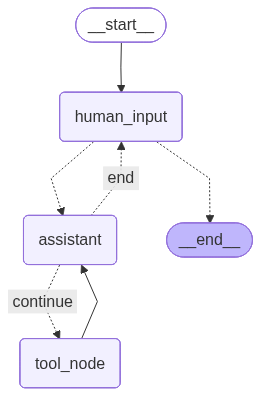

In [20]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from typing import Literal

# Human-in-the-loop node: pauses the graph and waits for a user message.
# Typing "done" ends the conversation.
def human_input(state: State) -> Command[Literal["assistant", "__end__"]]:
    user_message = interrupt("Enter your message (or 'done' to quit):")

    if user_message.strip().lower() == "done":
        return Command(goto=END)

    # NOTE THE USE OF THE "COMMAND" OBJECT TO EXPLICITLY CONTROL THE GRAPH FLOW

    return Command(
        update={"messages": [HumanMessage(content=user_message)]},
        goto="assistant",
    )

# INITIAILIZE THE GRAPH
builder = StateGraph(State)

# ADD NODES TO THE GRAPH
builder.add_node("human_input", human_input)
builder.add_node("assistant", assistant)
builder.add_node("tool_node", tool_node)

# ADD A STARTING EDGE TO THE GRAPH
builder.add_edge(START, "human_input")

# After the assistant, either call tools or loop back for another user turn
builder.add_conditional_edges(
    "assistant",
    should_continue,
    {
        # If `continue`, then we call the tool node.
        "continue": "tool_node",
        # Otherwise, loop back to wait for the next user message
        "end": "human_input",
    },
)

# Always return to the LLM after calling tools
builder.add_edge("tool_node", "assistant")

# interrupt() requires a checkpointer to persist state between turns
agent = builder.compile(name="agent", checkpointer=InMemorySaver())
agent

We've rebuilt a ReAct agent from scratch — this time with a human-in-the-loop node that keeps the conversation running until you type `done`. Each time the graph reaches the `human_input` node, it pauses at `interrupt()` and waits for your next message, then we resume the graph with `Command(resume=...)`.

Run the cell below, then type messages at the prompt. Try asking about weather or movies, then have a follow-up conversation. Type `done` to exit.

In [21]:
from langgraph.types import Command
from langsmith import uuid7

config = {"configurable": {"thread_id": uuid7()}}

# Kick off the graph - it pauses immediately at the first human_input interrupt
state = agent.invoke({"messages": []}, config=config)

seen = 0
while "__interrupt__" in state:
    prompt = state["__interrupt__"][0].value
    user_message = input(f"{prompt} ")

    state = agent.invoke(Command(resume=user_message), config=config)

    # Print any new messages produced this turn (tool calls, tool results, AI reply)
    for msg in state.get("messages", [])[seen:]:
        msg.pretty_print()
    seen = len(state.get("messages", []))

print("\nConversation ended.")


Conversation ended.


## 🎉 Congratulations!

You've learned the core concepts of building agents with LangChain and LangGraph:

 **Models** - Standardized interface across providers  
 **Messages** - Building block of conversations  
 **Tools** - Extending LLM capabilities  
 **Agents** - Automated reasoning and action loops  
 **Memory** - Maintaining context across interactions  
 **Streaming** - Real-time user experience  
 **LangGraph** - The foundation powering it all

### What's Next?

1. **Build your own agent** with your specific tools and use case
2. **Explore advanced patterns** in the `multi_agent.ipynb` notebook
3. **Add debugging** with [LangSmith](https://smith.langchain.com)
4. **Deploy to production** using LangGraph's persistence and error recovery

### Resources:

- [LangChain Documentation](https://python.langchain.com/docs/introduction/)
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [LangSmith for Debugging](https://smith.langchain.com)
- [LangChain Academy](https://academy.langchain.com/)
<br> 
<br> 
---
<br> 

**Happy building!**